# Experiment 1 — Broad Architecture Search

**Magnetic Source Identification · MTH 5320 Project 1 · Strider Settgast**

One of three self-contained experiment notebooks recording the search for a multi-task neural network that localizes and classifies simulated ionospheric magnetic sources from a 29-station magnetometer array.

- **Experiment 1 (this notebook)** — broad search across all 14 hyperparameters.
- `02_Experiment_2.ipynb` — locks Exp 1's decisive winners, tunes loss/optimizer.
- `03_Experiment_3.ipynb` — larger dataset + grad_clip fix, full evaluation & Bayes analysis.

> **How to run (Google Colab):** this notebook is **self-contained**. Open it in Colab, set **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**. The first cell installs `optuna` + `tqdm` and prompts you to upload **`L058.txt`** (the 29-station sensor file). Data generation and the train/validation split are seeded, so results are reproducible up to the small randomness in Optuna's search.

## 0 · Environment Setup
Installs `optuna` and `tqdm`, then prompts you to upload the sensor file `L058.txt` when the file picker appears.

In [ ]:
# ============================================================
# Environment Setup — run this first
# ============================================================
# Colab ships with PyTorch and sklearn pre-installed.
# Optuna and tqdm are the only additions needed.
!pip install optuna tqdm --quiet

# Sensor location file (L058.txt):
#   - If it is already next to this notebook (e.g. a cloned repo), use it.
#   - Otherwise, on Colab, prompt for an upload.
import os
if os.path.exists('L058.txt'):
    print('Found L058.txt in the working directory \u2014 no upload needed.')
else:
    try:
        from google.colab import files
        uploaded = files.upload()  # prompts for L058.txt
    except ImportError:
        raise FileNotFoundError(
            'L058.txt not found. Place it next to this notebook (or upload it on Colab).'
        )


## 1 · Simulation & Model Infrastructure
The cells in this section are **shared infrastructure — identical across all three experiment notebooks**. They define the magnetic-field simulator, load the sensor array, build the multi-task network, and set up the Optuna search. Only **Section 2** (dataset parameters) and **Section 3** (the experiment that is run) differ between the three notebooks.

### 1.1 Magnetometer Time Series Simulator (MTSS)

In [2]:
"""
Magnetometer Time Series Simulator for Magnetic Localization Research

This module provides a high-fidelity simulator for generating synthetic
magnetometer data from dipole sources, designed for training neural networks
for magnetic source localization.

Author: Strider Settgast with Deepseek
Date: 2026-06-01
Version: 1.0.0
"""

import numpy as np
from typing import Optional, Tuple, Dict, List
from dataclasses import dataclass
import warnings
from enum import Enum


class SourceType(Enum):
    """Types of magnetic sources that can be simulated."""
    DIPOLE = "dipole"
    MONOPOLE = "monopole"  # Not physically real but useful for testing
    #QUADRUPOLE = "quadrupole"


class NoiseModel(Enum):
    """Available noise models for sensor simulation."""
    GAUSSIAN = "gaussian"
    UNIFORM = "uniform"
    MIXED = "mixed"  # Combination of Gaussian and outliers


@dataclass
class SimulatorConfig:
    """
    Configuration class for the TimeSeriesSimulator.

    Attributes:
        sensor_positions: (n_sensors, 3) array of sensor coordinates
        n_sensors: Number of sensors (auto-detected from positions)
        magnetic_constant: mu_0/(4pi) in SI units (default 1e-7 for normalized)
        default_source_bounds: [min, max] for source position cube
        default_moment_range: [min, max] for magnetic moment magnitude
        noise_std: Standard deviation for Gaussian noise
        noise_outlier_fraction: Fraction of outliers for robust testing
        random_seed: For reproducibility
        normalize_outputs: Whether to normalize target positions
        output_bounds: Bounds for output normalization (if used)
    """
    sensor_positions: np.ndarray
    magnetic_constant: float = 1e-7  # mu_0/(4pi) in SI, or 1.0 for normalized
    default_source_bounds: Tuple[float, float] = (-5.0, 5.0)
    default_moment_range: Tuple[float, float] = (0.5, 2.0)
    noise_std: float = 0.01
    noise_outlier_fraction: float = 0.01
    random_seed: Optional[int] = 42
    normalize_outputs: bool = False
    output_bounds: Optional[Tuple[float, float]] = None

    def __post_init__(self):
        """Validate configuration after initialization."""
        self.n_sensors = len(self.sensor_positions)
        if self.sensor_positions.shape[1] != 3:
            raise ValueError(f"Sensor positions must have 3 columns, got {self.sensor_positions.shape[1]}")

        if self.random_seed is not None:
            np.random.seed(self.random_seed)

        if self.output_bounds is None:
            self.output_bounds = self.default_source_bounds


class TimeSeriesSimulator:
    """
    Industry-grade simulator for magnetometer time series data.

    This class generates realistic magnetic field readings from moving or static
    dipole sources, with configurable noise, sensor layouts, and source dynamics.

    Features:
        - Static and moving source simulation
        - Multiple noise models (Gaussian, uniform, mixed)
        - Sensor noise and dropout simulation
        - Temporal correlation for realistic time series
        - Batching and streaming data generation
        - Built-in visualization tools

    Examples:
        >>> # Initialize with sensor positions
        >>> sensor_positions = np.random.rand(29, 3) * 10
        >>> sim = TimeSeriesSimulator(sensor_positions)
        >>>
        >>> # Generate static source data
        >>> X, y = sim.generate_batch(n_samples=1000)
        >>>
        >>> # Generate moving source time series
        >>> trajectory = lambda t: np.array([np.sin(t), np.cos(t), t*0.1])
        >>> X_series, y_series = sim.generate_time_series(
        ...     n_timesteps=500,
        ...     trajectory_func=trajectory
        ... )
    """

    def __init__(self, sensor_positions: np.ndarray, config: Optional[SimulatorConfig] = None):
        """
        Initialize the simulator with sensor geometry.

        Args:
            sensor_positions: (n_sensors, 3) array of sensor coordinates in meters
            config: Optional SimulatorConfig object. If None, uses defaults.
        """
        self.sensor_positions = sensor_positions
        self.n_sensors = len(sensor_positions)

        if config is None:
            config = SimulatorConfig(sensor_positions=sensor_positions)
        else:
            config.sensor_positions = sensor_positions
            config.__post_init__()

        self.config = config
        self._validate_sensor_positions()

        # Pre-compute sensor positions for efficiency
        self.sensor_positions = config.sensor_positions
        self.n_sensors = config.n_sensors
        self.n_features = self.n_sensors * 3  # Bx, By, Bz for each sensor

        # Statistics for online normalization (if needed)
        self.input_mean = None
        self.input_std = None
        self.output_mean = None
        self.output_std = None

        print(f"✅ Simulator initialized: {self.n_sensors} sensors, {self.n_features} features")

    def _validate_sensor_positions(self):
        """Validate that sensor positions are physically reasonable."""
        if np.any(np.isnan(self.sensor_positions)):
            raise ValueError("Sensor positions contain NaN values")
        if np.any(np.isinf(self.sensor_positions)):
            raise ValueError("Sensor positions contain infinite values")

        # Check for duplicate sensors (within 1mm tolerance)
        unique_positions = np.unique(np.round(self.sensor_positions, decimals=6), axis=0)
        if len(unique_positions) < self.n_sensors:
            warnings.warn(f"Duplicate sensor positions detected. {self.n_sensors - len(unique_positions)} duplicates found.")

    def monopole_field(self,
                       sensor_pos: np.ndarray,
                       source_pos: np.ndarray,
                       magnetic_charge: float) -> np.ndarray:
        """
        Calculate magnetic field from a theoretical monopole (1/r^2 falloff).
        """
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        B = (r_hat) / (r**2)
        B *= self.config.magnetic_constant * magnetic_charge

        return B

    def dipole_field(self,
                     sensor_pos: np.ndarray,
                     source_pos: np.ndarray,
                     magnetic_moment: np.ndarray) -> np.ndarray:
        """
        Calculate magnetic field from a dipole source at a single sensor.

        Args:
            sensor_pos: (3,) array of sensor position [x, y, z]
            source_pos: (3,) array of source position [x, y, z]
            magnetic_moment: (3,) array of magnetic moment vector [mx, my, mz]

        Returns:
            (3,) array of magnetic field [Bx, By, Bz] in Tesla (or normalized units)

        Raises:
            ValueError: If inputs have incorrect shapes
        """
        # Input validation
        if sensor_pos.shape != (3,):
            raise ValueError(f"sensor_pos must be (3,), got {sensor_pos.shape}")
        if source_pos.shape != (3,):
            raise ValueError(f"source_pos must be (3,), got {source_pos.shape}")
        if magnetic_moment.shape != (3,):
            raise ValueError(f"magnetic_moment must be (3,), got {magnetic_moment.shape}")

        # Calculate relative position vector
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)

        # Avoid division by zero (sensor at source location)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        m_dot_r_hat = np.dot(magnetic_moment, r_hat)

        # Dipole field equation
        B = (3 * r_hat * m_dot_r_hat - magnetic_moment) / (r**3)

        # Apply magnetic constant (normalization)
        B *= self.config.magnetic_constant

        return B


    def generate_source(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a random magnetic source (position and moment).

        Returns:
            Tuple of (source_position, magnetic_moment)

        Note:
            Position is uniform within source_bounds.
            Moment magnitude is uniform within moment_range.
            Moment direction is uniformly distributed on sphere.
        """
        # Random source position within bounds
        low, high = self.config.default_source_bounds
        source_pos = np.random.uniform(low, high, size=3)

        # Random magnetic moment magnitude
        mag_low, mag_high = self.config.default_moment_range
        moment_magnitude = np.random.uniform(mag_low, mag_high)

        # Random direction on sphere (uniform distribution)
        direction = np.random.randn(3)
        direction /= np.linalg.norm(direction)

        magnetic_moment = direction * moment_magnitude

        return source_pos, magnetic_moment

    def compute_fields(self, source_pos: np.ndarray, magnetic_moment: np.ndarray, source_type: SourceType = SourceType.DIPOLE) -> np.ndarray:
        """
        Compute magnetic fields at all sensors for a given source.

        Args:
            source_pos: (3,) array of source position
            magnetic_moment: (3,) array of magnetic moment
            source_type: The type of magnetic source (Enum)

        Returns:
            (n_features,) array of flattened sensor readings (Bx,By,Bz for each sensor)
        """
        fields = []
        for sensor_pos in self.sensor_positions:
            if source_type == SourceType.DIPOLE:
                B = self.dipole_field(sensor_pos, source_pos, magnetic_moment)
            elif source_type == SourceType.MONOPOLE:
                charge = np.linalg.norm(magnetic_moment)
                B = self.monopole_field(sensor_pos, source_pos, charge)

            fields.extend(B)

        return np.array(fields)

    def add_noise(self,
                  fields: np.ndarray,
                  noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> np.ndarray:
        """
        Add realistic noise to sensor readings.

        Args:
            fields: Clean magnetic field readings
            noise_model: Type of noise to add

        Returns:
            Noisy field readings
        """
        noisy = fields.copy()

        if noise_model == NoiseModel.GAUSSIAN:
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.UNIFORM:
            noise_range = self.config.noise_std * np.sqrt(3)  # Match variance
            noise = np.random.uniform(-noise_range, noise_range, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.MIXED:
            # Gaussian noise
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

            # Add outliers
            n_outliers = int(len(fields) * self.config.noise_outlier_fraction)
            outlier_indices = np.random.choice(len(fields), n_outliers, replace=False)
            outlier_magnitude = self.config.noise_std * 10
            noisy[outlier_indices] += np.random.normal(0, outlier_magnitude, size=n_outliers)

        return noisy

    def generate_sample(self,
                        source_pos: Optional[np.ndarray] = None,
                        magnetic_moment: Optional[np.ndarray] = None,
                        add_noise: bool = True,
                        noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a single training sample.

        Args:
            source_pos: Optional source position (random if None)
            magnetic_moment: Optional magnetic moment (random if None)
            add_noise: Whether to add noise to the readings
            noise_model: Which noise model to use

        Returns:
            Tuple of (features, target) where:
                features: (n_features,) array of magnetic field readings
                target: (3,) array of source position
        """
        random_pos, random_moment = self.generate_source()

        if source_pos is None:
            source_pos = random_pos
        if magnetic_moment is None:
            magnetic_moment = random_moment

        fields = self.compute_fields(source_pos, magnetic_moment)

        if add_noise:
            fields = self.add_noise(fields, noise_model)

        target = source_pos.copy()

        # Optional output normalization
        if self.config.normalize_outputs:
            low, high = self.config.output_bounds
            target = (target - low) / (high - low) * 2 - 1  # Normalize to [-1, 1]

        return fields, target

    def generate_batch(self,
                       n_samples: int,
                       add_noise: bool = True,
                       noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a batch of training samples.

        Args:
            n_samples: Number of samples to generate
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_samples, n_features) array of features
                y: (n_samples, 3) array of targets
        """
        X = np.zeros((n_samples, self.n_features))
        y = np.zeros((n_samples, 3))

        for i in range(n_samples):
            X[i], y[i] = self.generate_sample(add_noise=add_noise, noise_model=noise_model)

        return X, y

    def generate_time_series(self,
                            n_timesteps: int,
                            trajectory_func: Optional[callable] = None,
                            moment_func: Optional[callable] = None,
                            dt: float = 0.01,
                            add_noise: bool = True,
                            noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a time series with moving source.

        Args:
            n_timesteps: Number of time steps to generate
            trajectory_func: Function t -> (x, y, z) position.
                            If None, uses random walk.
            moment_func: Function t -> (mx, my, mz) magnetic moment.
                        If None, uses constant random moment.
            dt: Time step duration in seconds
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_timesteps, n_features) time series of features
                y: (n_timesteps, 3) time series of source positions

        Examples:
            >>> # Linear motion
            >>> def linear_motion(t):
            ...     return np.array([t, 0, 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=linear_motion)

            >>> # Circular motion with sinusoidal moment
            >>> def circular_motion(t):
            ...     return np.array([np.sin(t), np.cos(t), 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=circular_motion)
        """
        times = np.arange(n_timesteps) * dt

        if trajectory_func is None:
            # Random walk trajectory
            positions = np.zeros((n_timesteps, 3))
            positions[0] = np.random.uniform(*self.config.default_source_bounds, size=3)
            step_size = 0.1
            for t in range(1, n_timesteps):
                positions[t] = positions[t-1] + np.random.randn(3) * step_size
                # Keep within bounds (soft boundary with reflection)
                low, high = self.config.default_source_bounds
                for dim in range(3):
                    if positions[t, dim] < low:
                        positions[t, dim] = low + (low - positions[t, dim])
                    elif positions[t, dim] > high:
                        positions[t, dim] = high - (positions[t, dim] - high)
        else:
            positions = np.array([trajectory_func(t) for t in times])

        if moment_func is None:
            # Constant random moment
            _, magnetic_moment = self.generate_source()
            moments = np.tile(magnetic_moment, (n_timesteps, 1))
        else:
            moments = np.array([moment_func(t) for t in times])

        # Generate fields for each time step
        X = np.zeros((n_timesteps, self.n_features))
        y = positions.copy()

        for i in range(n_timesteps):
            fields = self.compute_fields(positions[i], moments[i])
            if add_noise:
                fields = self.add_noise(fields, noise_model)
            X[i] = fields

        return X, y

    def compute_snr(self, clean_fields: np.ndarray, noisy_fields: np.ndarray) -> float:
        """
        Compute Signal-to-Noise Ratio for generated data.

        Args:
            clean_fields: Clean magnetic field readings
            noisy_fields: Noisy readings

        Returns:
            SNR in decibels (dB)
        """
        signal_power = np.mean(clean_fields ** 2)
        noise_power = np.mean((clean_fields - noisy_fields) ** 2)

        if noise_power < 1e-12:
            return float('inf')

        snr = 10 * np.log10(signal_power / noise_power)
        return snr

    def get_data_statistics(self, X: np.ndarray, y: np.ndarray) -> Dict[str, Dict[str, float]]:
        """
        Compute comprehensive statistics for generated data.

        Args:
            X: Features array (n_samples, n_features)
            y: Targets array (n_samples, 3)

        Returns:
            Dictionary with statistics for inputs and outputs
        """
        stats = {
            'input': {
                'mean': np.mean(X, axis=0).tolist(),
                'std': np.std(X, axis=0).tolist(),
                'min': np.min(X, axis=0).tolist(),
                'max': np.max(X, axis=0).tolist(),
                'has_nan': np.any(np.isnan(X)),
                'has_inf': np.any(np.isinf(X))
            },
            'output': {
                'mean': np.mean(y, axis=0).tolist(),
                'std': np.std(y, axis=0).tolist(),
                'min': np.min(y, axis=0).tolist(),
                'max': np.max(y, axis=0).tolist(),
                'has_nan': np.any(np.isnan(y)),
                'has_inf': np.any(np.isinf(y))
            }
        }
        return stats

    def visualize_sensor_array(self, ax=None):
        """
        Visualize the 3D positions of sensors.

        Args:
            ax: Matplotlib 3D axis (creates new if None)
        """
        try:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D

            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax = fig.add_subplot(111, projection='3d')

            ax.scatter(self.sensor_positions[:, 0],
                      self.sensor_positions[:, 1],
                      self.sensor_positions[:, 2],
                      c='red', marker='o', s=50, label='Sensors')

            ax.set_xlabel('X (m)')
            ax.set_ylabel('Y (m)')
            ax.set_zlabel('Z (m)')
            ax.set_title(f'Sensor Array Layout ({self.n_sensors} Sensors)')
            ax.legend()

            # Set equal aspect ratio
            max_range = np.max([
                np.ptp(self.sensor_positions[:, 0]),
                np.ptp(self.sensor_positions[:, 1]),
                np.ptp(self.sensor_positions[:, 2])
            ]) / 2.0
            mid_x = np.mean(self.sensor_positions[:, 0])
            mid_y = np.mean(self.sensor_positions[:, 1])
            mid_z = np.mean(self.sensor_positions[:, 2])
            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)

            return ax

        except ImportError:
            print("Matplotlib not available. Install with: pip install matplotlib")
            return None

    def save_dataset(self, X: np.ndarray, y: np.ndarray, filepath: str):
        """
        Save generated dataset to disk (NPZ format).

        Args:
            X: Features array
            y: Targets array
            filepath: Path to save file (.npz extension recommended)
        """
        np.savez_compressed(filepath, X=X, y=y,
                           sensor_positions=self.sensor_positions,
                           config=vars(self.config))
        print(f"✅ Dataset saved to {filepath}")

    @classmethod
    def load_dataset(cls, filepath: str):
        """
        Load a saved dataset.

        Args:
            filepath: Path to saved .npz file

        Returns:
            Dictionary containing X, y, sensor_positions, and config
        """
        data = np.load(filepath, allow_pickle=True)
        return {
            'X': data['X'],
            'y': data['y'],
            'sensor_positions': data['sensor_positions'],
            'config': data['config'].item() if 'config' in data else None
        }

### 1.2 Sensor Array Loader (`L058.txt` → 29 stations)

In [3]:
import numpy as np
import pandas as pd


## Load the sensor locations

# Define column names
column_names = ['Station', 'Lshell', 'M_Lat', 'M_Lon', 'G_lat', 'G_lon']

# Read the file using read_fwf (fixed-width format)
locations_df = pd.read_fwf('L058.txt', names=column_names, skiprows=1)  # skiprows=1 to skip the "029" line

# Sort by station name
locations_df.sort_values(by='Station', inplace=True)

# --- 3D Cartesian Conversion ---
# Mean radius of Earth in kilometers (use 1.0 for a normalized unit sphere)
R = 6371.0

# Convert geographic latitude and longitude to radians
lat_rad = np.radians(locations_df["G_lat"])
lon_rad = np.radians(locations_df["G_lon"])

# Compute X, Y, and Z coordinates
locations_df["X"] = R * np.cos(lat_rad) * np.cos(lon_rad)
locations_df["Y"] = R * np.cos(lat_rad) * np.sin(lon_rad)
locations_df["Z"] = R * np.sin(lat_rad)

# Extract X, Y, Z columns into a 2D NumPy array
sensors_xyz_locations = locations_df[["X", "Y", "Z"]].to_numpy()

# Check the shape of your new array
print(f"\n \n✓ Loaded: - Sensor Locations {sensors_xyz_locations.shape[0]} rows × {sensors_xyz_locations.shape[1]} columns")
print(f"\nFirst 5 rows (preview):")
print(sensors_xyz_locations[:5, :5])


 
✓ Loaded: - Sensor Locations 29 rows × 3 columns

First 5 rows (preview):
[[-3933.43787518  3461.69610765 -3624.13679935]
 [-1456.21299991 -3381.28875582  5199.6125864 ]
 [-2151.33376015  4375.94273603  4100.30843027]
 [-4352.20723163  3755.39914318 -2746.80004522]
 [-4456.93788538  2677.99845678 -3681.53092495]]


### 1.3 Multi-Task Neural Network
A fully-connected multi-task network with a shared backbone and two task-specific heads:

- **Shared backbone** — processes the 87-dim magnetic-field reading (batch norm, dropout, activation).
- **Regression head** — predicts the 3D source position (x, y, z).
- **Classification head** — predicts the source type (monopole / dipole).

Residual connections, batch normalization, and task-specific heads are all configurable; the winning configuration is selected per experiment by the Optuna search.

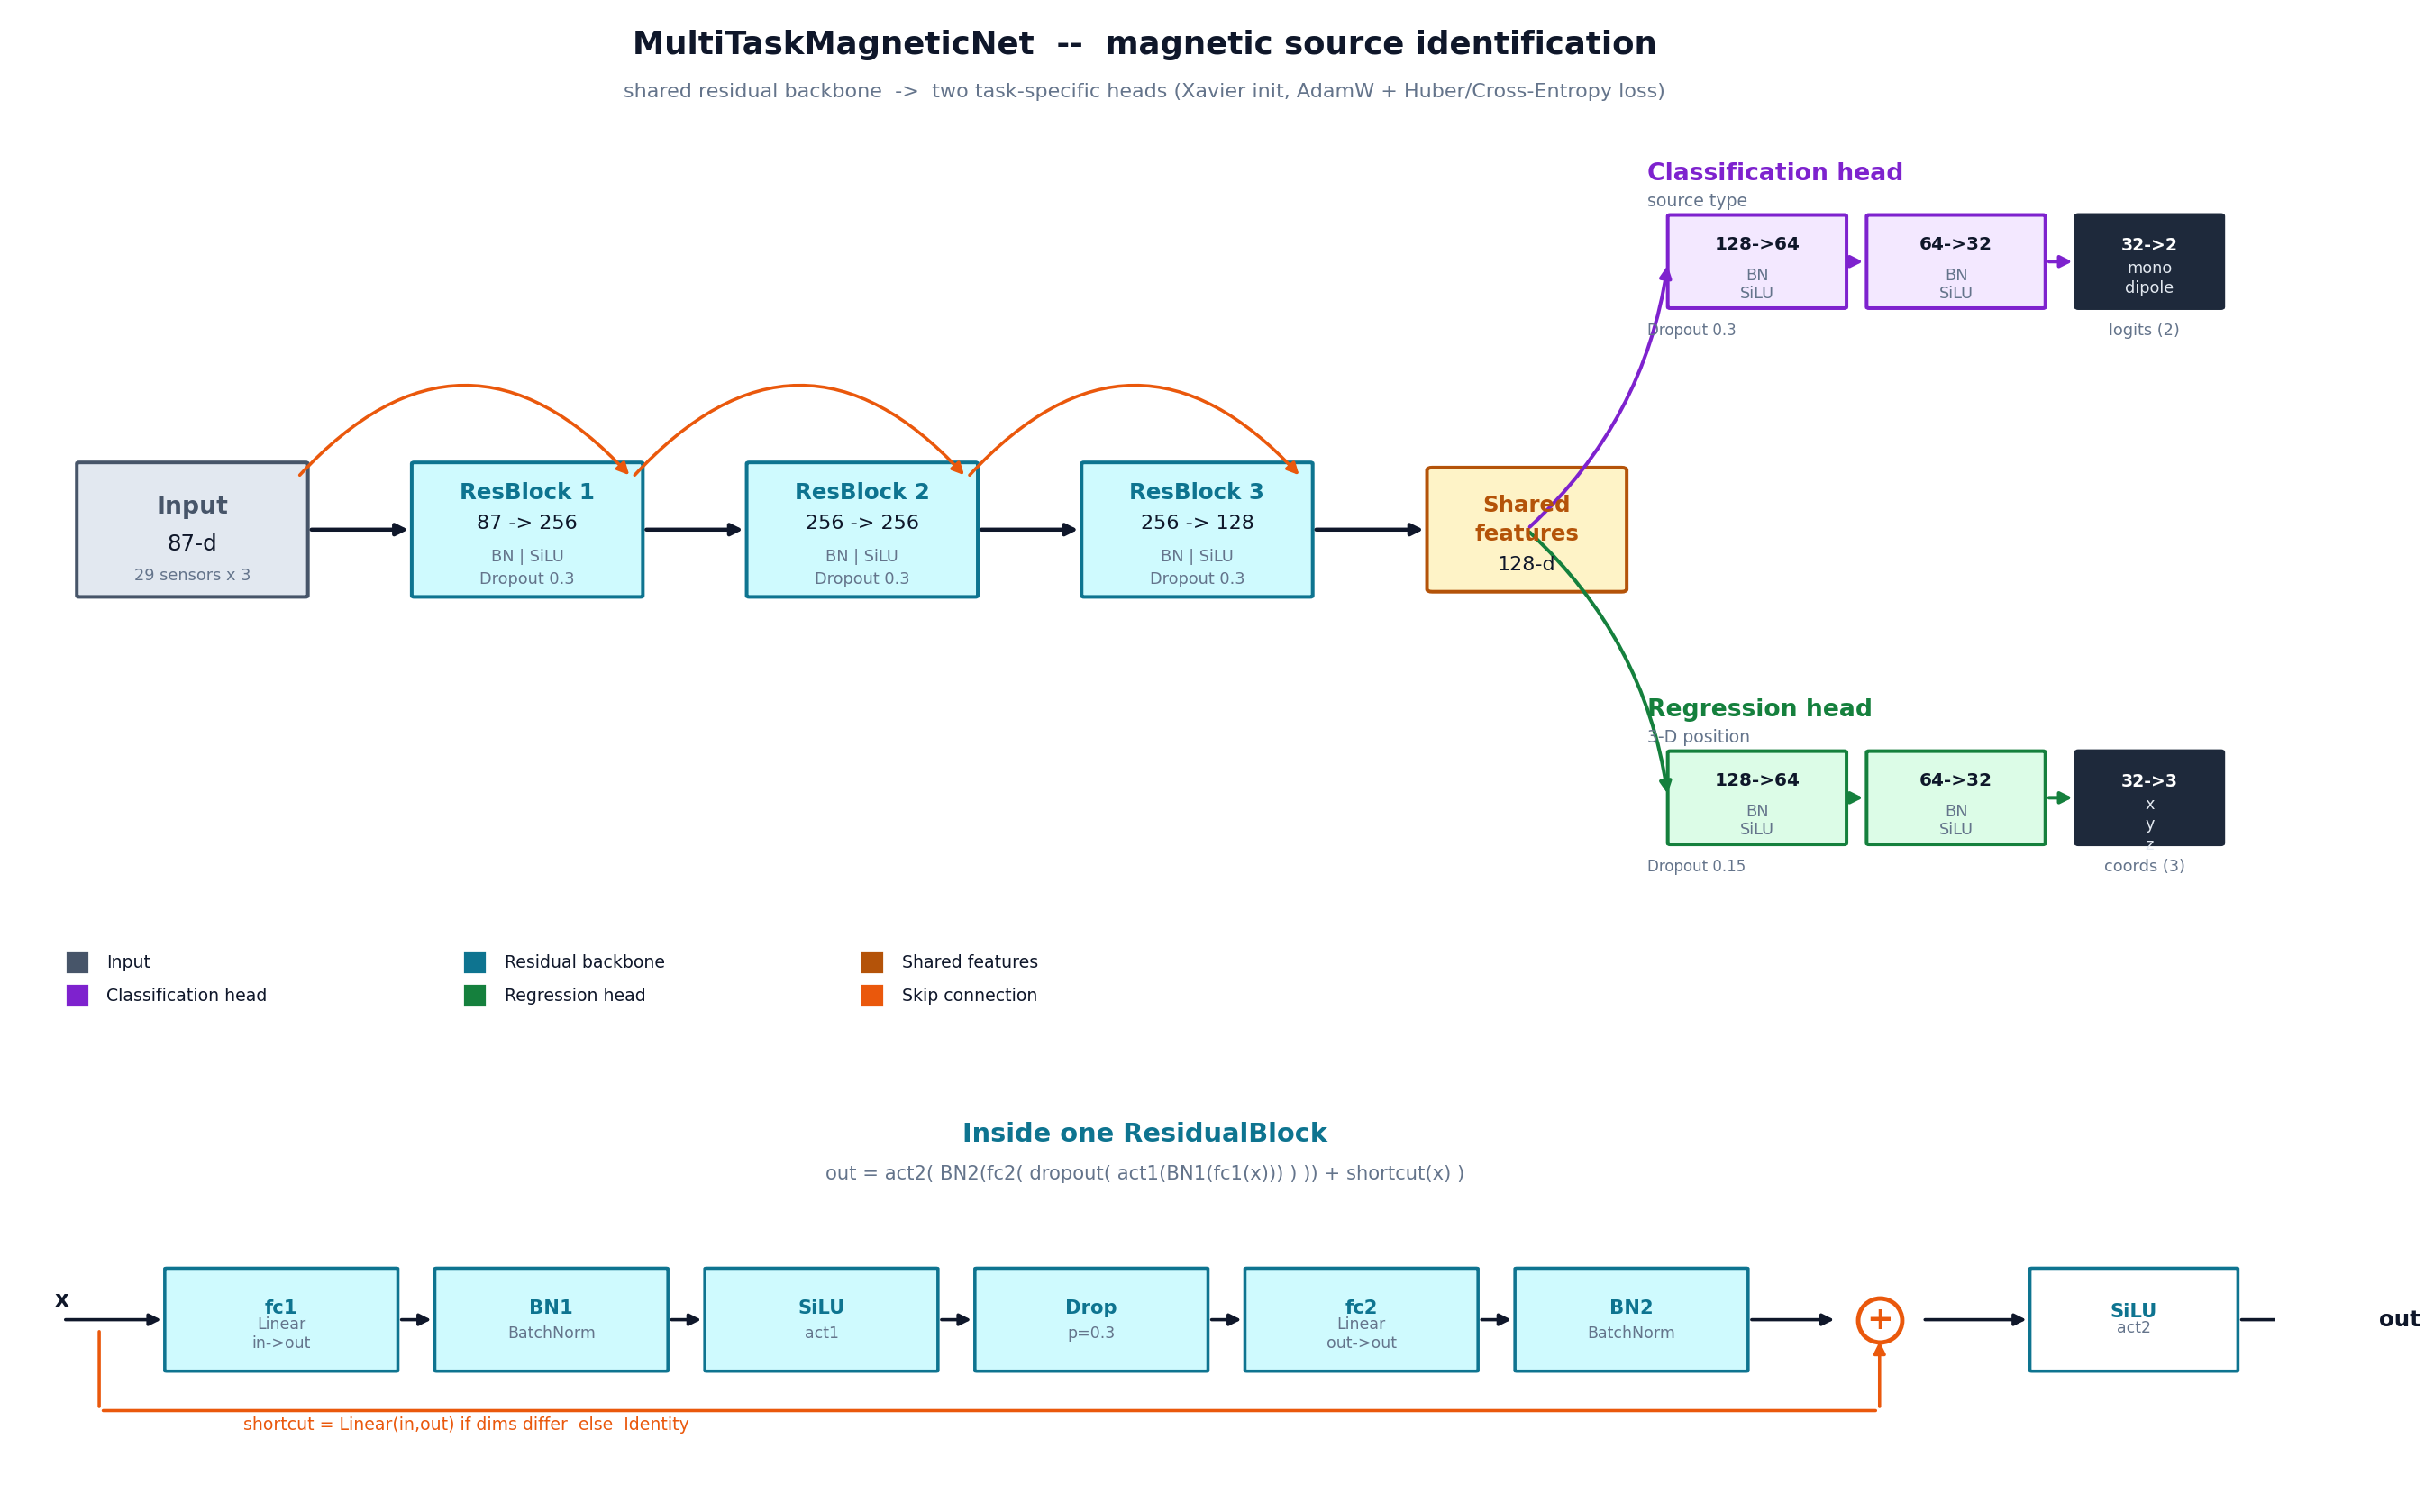

In [7]:
"""
Multi-Task Neural Network for Magnetic Source Identification
Industry-standard architecture with residual connections, batch normalization,
and proper regularization for geophysical inversion problems.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Dict, Tuple, Optional, List
from dataclasses import dataclass
import optuna
from optuna.trial import Trial
import warnings


@dataclass
class ModelConfig:
    """Configuration for the multi-task magnetic source identification model."""
    # Architecture
    input_dim: int = 87  # 29 sensors × 3 components
    hidden_dims: List[int] = None  # Will be set in __post_init__
    dropout_rate: float = 0.3
    activation: str = "silu"  # SiLU/Swish often better for geophysical data

    # Task-specific heads
    loc_hidden_dims: List[int] = None  # Regression head
    type_hidden_dims: List[int] = None  # Classification head

    # Regularization
    weight_decay: float = 1e-5
    batch_norm_momentum: float = 0.1
    use_residual: bool = True

    # Training
    learning_rate: float = 1e-3
    batch_size: int = 64           # Mini-batch size (tunable by Optuna)
    loc_loss_weight: float = 1.0  # Weight for position loss
    type_loss_weight: float = 1.0  # Weight for type classification loss

    def __post_init__(self):
        if self.hidden_dims is None:
            self.hidden_dims = [256, 256, 128]
        if self.loc_hidden_dims is None:
            self.loc_hidden_dims = [64, 32]
        if self.type_hidden_dims is None:
            self.type_hidden_dims = [64, 32]


class ResidualBlock(nn.Module):
    """Residual block with batch normalization and dropout.

    Uses a projection shortcut so the block works even when its input and
    output dimensions differ (standard ResNet practice). Each block also owns
    its own activation instances rather than sharing a single module passed in
    from the parent network.
    """

    @staticmethod
    def _make_activation(activation_type: str) -> nn.Module:
        if activation_type == "relu":
            return nn.ReLU()
        elif activation_type == "silu":
            return nn.SiLU()
        elif activation_type == "gelu":
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {activation_type}")

    def __init__(self, in_dim: int, out_dim: int, dropout_rate: float,
                 activation_type: str, bn_momentum: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim, momentum=bn_momentum)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim, momentum=bn_momentum)
        self.dropout = nn.Dropout(dropout_rate)

        # Project the residual when dimensions change so (x + residual) aligns.
        if in_dim != out_dim:
            self.shortcut = nn.Linear(in_dim, out_dim, bias=False)
        else:
            self.shortcut = nn.Identity()

        # Fresh activation instances owned by this block (no shared reference).
        self.activation1 = self._make_activation(activation_type)
        self.activation2 = self._make_activation(activation_type)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.shortcut(x)
        x = self.activation1(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.bn2(self.fc2(x))
        x = self.activation2(x + residual)
        return x


class MultiTaskMagneticNet(nn.Module):
    """
    Multi-task neural network for magnetic source localization and classification.

    Architecture:
    - Shared backbone: Processes magnetic field readings
    - Regression head: Predicts 3D source position (x, y, z)
    - Classification head: Predicts source type (monopole/dipole)

    Features:
    - Residual connections for better gradient flow
    - Batch normalization for stable training
    - Task-specific heads with proper output activations
    """

    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config

        # Activation function
        if config.activation == "relu":
            self.activation = nn.ReLU()
        elif config.activation == "silu":
            self.activation = nn.SiLU()
        elif config.activation == "gelu":
            self.activation = nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {config.activation}")

        # ========== Shared Backbone ==========
        layers = []
        prev_dim = config.input_dim

        for i, hidden_dim in enumerate(config.hidden_dims):
            if config.use_residual:
                # Projection shortcut handles any dimension change, so the
                # residual block can be applied to every layer unconditionally.
                layers.append(
                    ResidualBlock(prev_dim, hidden_dim, config.dropout_rate,
                                  config.activation, config.batch_norm_momentum)
                )
            else:
                layers.append(nn.Linear(prev_dim, hidden_dim))
                layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
                layers.append(self.activation)
                layers.append(nn.Dropout(config.dropout_rate))

            prev_dim = hidden_dim

        self.shared_backbone = nn.Sequential(*layers)
        self.shared_dim = prev_dim

        # ========== Regression Head (Position) ==========
        loc_layers = []
        prev_dim = self.shared_dim

        for hidden_dim in config.loc_hidden_dims:
            loc_layers.append(nn.Linear(prev_dim, hidden_dim))
            loc_layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
            loc_layers.append(self._make_activation())  # fresh instance per layer
            loc_layers.append(nn.Dropout(config.dropout_rate * 0.5))  # less dropout for regression
            prev_dim = hidden_dim

        # Output layer - no activation (raw coordinates, will be scaled by target_scaler)
        loc_layers.append(nn.Linear(prev_dim, 3))
        self.regression_head = nn.Sequential(*loc_layers)

        # ========== Classification Head (Source Type) ==========
        type_layers = []
        prev_dim = self.shared_dim

        for hidden_dim in config.type_hidden_dims:
            type_layers.append(nn.Linear(prev_dim, hidden_dim))
            type_layers.append(nn.BatchNorm1d(hidden_dim, momentum=config.batch_norm_momentum))
            type_layers.append(self._make_activation())  # fresh instance per layer
            type_layers.append(nn.Dropout(config.dropout_rate))
            prev_dim = hidden_dim

        # Output layer - logits for 2 classes (monopole, dipole)
        type_layers.append(nn.Linear(prev_dim, 2))
        self.classification_head = nn.Sequential(*type_layers)

        # Initialize weights
        self._initialize_weights()

    def _make_activation(self) -> nn.Module:
        """Return a fresh, independent activation instance.

        Each call produces a new object so no two layers in the network
        share the same module reference — avoiding inplace-operation
        conflicts and double-registration in PyTorch's module graph.
        """
        if self.config.activation == "relu":  return nn.ReLU()
        elif self.config.activation == "silu": return nn.SiLU()
        elif self.config.activation == "gelu": return nn.GELU()

    def _initialize_weights(self):
        """Initialize weights using Xavier initialization."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch_size, input_dim)

        Returns:
            loc_pred: Position predictions of shape (batch_size, 3)
            type_pred: Type logits of shape (batch_size, 2)
        """
        # Shared features
        features = self.shared_backbone(x)

        # Task-specific predictions
        loc_pred = self.regression_head(features)
        type_pred = self.classification_head(features)

        return loc_pred, type_pred


class MagneticSourceLoss(nn.Module):
    """
    Combined loss for multi-task learning.

    Uses:
    - Huber loss (smooth L1) for position regression (robust to outliers)
    - Cross-entropy loss for source type classification

    Adaptive weighting based on uncertainty (optional).
    """

    def __init__(self, loc_weight: float = 1.0, type_weight: float = 1.0,
                 use_uncertainty_weighting: bool = False, huber_beta: float = 0.1):
        """
        Args:
            loc_weight: Weight for position loss
            type_weight: Weight for classification loss
            use_uncertainty_weighting: Learn task weights automatically (Kendall et al. 2018)
        """
        super().__init__()
        self.loc_weight = loc_weight
        self.type_weight = type_weight
        self.use_uncertainty_weighting = use_uncertainty_weighting

        if use_uncertainty_weighting:
            # Learnable log variances for each task
            self.log_var_loc = nn.Parameter(torch.zeros(1))
            self.log_var_type = nn.Parameter(torch.zeros(1))

        self.loc_loss_fn = nn.SmoothL1Loss(beta=huber_beta)  # Huber loss
        self.type_loss_fn = nn.CrossEntropyLoss()

    def forward(self, loc_pred: torch.Tensor, type_pred: torch.Tensor,
                loc_true: torch.Tensor, type_true: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Compute combined loss.

        Args:
            loc_pred: Predicted positions (batch_size, 3)
            type_pred: Predicted type logits (batch_size, 2)
            loc_true: True positions (batch_size, 3)
            type_true: True type indices (batch_size,)

        Returns:
            Dictionary containing individual losses and total loss
        """
        # Position loss (regression)
        loc_loss = self.loc_loss_fn(loc_pred, loc_true)

        # Type loss (classification)
        type_loss = self.type_loss_fn(type_pred, type_true)

        if self.use_uncertainty_weighting:
            # Uncertainty-weighted multi-task loss
            # L = (1/2) * (L1 / exp(s1) + s1 + L2 / exp(s2) + s2)
            loc_weighted = 0.5 * (loc_loss / torch.exp(self.log_var_loc) + self.log_var_loc)
            type_weighted = 0.5 * (type_loss / torch.exp(self.log_var_type) + self.log_var_type)
            total_loss = loc_weighted + type_weighted
        else:
            total_loss = self.loc_weight * loc_loss + self.type_weight * type_loss

        return {
            'total_loss': total_loss,
            'loc_loss': loc_loss,
            'type_loss': type_loss,
            'loc_rmse': torch.sqrt(torch.mean((loc_pred - loc_true) ** 2)),
            'type_acc': (type_pred.argmax(dim=1) == type_true).float().mean()
        }


class EarlyStopping:
    """Early stopping to prevent overfitting."""

    def __init__(self, patience: int = 20, min_delta: float = 1e-5, mode: str = 'min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state_dict = None

    def __call__(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False

        if self.mode == 'min':
            improved = score < self.best_score - self.min_delta
        else:
            improved = score > self.best_score + self.min_delta

        if improved:
            self.best_score = score
            self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        return self.early_stop


class ModelTrainer:
    """Industry-standard trainer with metrics tracking and checkpointing."""

    def __init__(self, model: nn.Module, device: torch.device, config: ModelConfig):
        self.model = model.to(device)
        self.device = device
        self.config = config

        # Optimizer with weight decay and momentum
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
            betas=(0.9, 0.999)
        )

        # Learning rate scheduler with warmup
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=10
        )

        self.criterion = MagneticSourceLoss(
            loc_weight=config.loc_loss_weight,
            type_weight=config.type_loss_weight
        )

        # Metrics tracking
        self.train_history = {'loss': [], 'loc_loss': [], 'type_loss': [], 'loc_rmse': [], 'type_acc': []}
        self.val_history = {'loss': [], 'loc_loss': [], 'type_loss': [], 'loc_rmse': [], 'type_acc': []}

    def train_epoch(self, train_loader: DataLoader) -> Dict[str, float]:
        """Train for one epoch."""
        self.model.train()
        epoch_metrics = {'loss': 0, 'loc_loss': 0, 'type_loss': 0, 'loc_rmse': 0, 'type_acc': 0}

        for X_batch, loc_batch, type_batch in train_loader:
            X_batch = X_batch.to(self.device)
            loc_batch = loc_batch.to(self.device)
            type_batch = type_batch.to(self.device)

            # Forward pass
            loc_pred, type_pred = self.model(X_batch)
            loss_dict = self.criterion(loc_pred, type_pred, loc_batch, type_batch)

            # Backward pass
            self.optimizer.zero_grad()
            loss_dict['total_loss'].backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            # Accumulate metrics
            for key in epoch_metrics.keys():
                # Loss dict exposes the combined loss as 'total_loss';
                # map our 'loss' accumulator onto it so the keys line up.
                src_key = 'total_loss' if key == 'loss' else key
                epoch_metrics[key] += loss_dict[src_key].item()

        # Average metrics
        n_batches = len(train_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

    @torch.no_grad()
    def evaluate(self, val_loader: DataLoader) -> Dict[str, float]:
        """Evaluate model on validation set."""
        self.model.eval()
        epoch_metrics = {'loss': 0, 'loc_loss': 0, 'type_loss': 0, 'loc_rmse': 0, 'type_acc': 0}

        for X_batch, loc_batch, type_batch in val_loader:
            X_batch = X_batch.to(self.device)
            loc_batch = loc_batch.to(self.device)
            type_batch = type_batch.to(self.device)

            loc_pred, type_pred = self.model(X_batch)
            loss_dict = self.criterion(loc_pred, type_pred, loc_batch, type_batch)

            for key in epoch_metrics.keys():
                # Loss dict exposes the combined loss as 'total_loss';
                # map our 'loss' accumulator onto it so the keys line up.
                src_key = 'total_loss' if key == 'loss' else key
                epoch_metrics[key] += loss_dict[src_key].item()

        n_batches = len(val_loader)
        return {k: v / n_batches for k, v in epoch_metrics.items()}

    def train(self, train_loader: DataLoader, val_loader: DataLoader,
              epochs: int = 200, early_stopping_patience: int = 30) -> Dict:
        """Complete training loop with early stopping."""
        early_stopping = EarlyStopping(patience=early_stopping_patience, mode='min')
        best_val_loss = float('inf')

        for epoch in range(epochs):
            # Train
            train_metrics = self.train_epoch(train_loader)
            for key, value in train_metrics.items():
                self.train_history[key].append(value)

            # Validate
            val_metrics = self.evaluate(val_loader)
            for key, value in val_metrics.items():
                self.val_history[key].append(value)

            # Learning rate scheduling
            self.scheduler.step(val_metrics['loss'])

            # Print progress
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} | "
                      f"Train Loss: {train_metrics['loss']:.4f} | "
                      f"Val Loss: {val_metrics['loss']:.4f} | "
                      f"Val Loc RMSE: {val_metrics['loc_rmse']:.4f} | "
                      f"Val Type Acc: {val_metrics['type_acc']:.4f}")

            # Early stopping
            if early_stopping(val_metrics['loss'], self.model):
                print(f"Early stopping triggered at epoch {epoch+1}")
                self.model.load_state_dict(early_stopping.best_state_dict)
                break

        return {
            'train_history': self.train_history,
            'val_history': self.val_history,
            'best_val_loss': early_stopping.best_score if early_stopping.best_score else best_val_loss
        }

### 1.4 Optuna Search Helpers

In [8]:
# ========== Optuna Hyperparameter Optimization ==========

def create_optuna_config(trial: Trial) -> ModelConfig:
    """Create model configuration from Optuna trial parameters."""

    # Architecture parameters
    n_layers = trial.suggest_int('n_layers', 2, 5)
    hidden_dim = trial.suggest_int('hidden_dim', 64, 512, step=32)

    # Decay pattern: can have decreasing or constant hidden dimensions
    decay_factor = trial.suggest_float('decay_factor', 0.7, 1.0)
    hidden_dims = [int(hidden_dim * (decay_factor ** i)) for i in range(n_layers)]
    hidden_dims = [max(32, d) for d in hidden_dims]  # Keep minimum 32

    # Head architectures
    n_loc_layers = trial.suggest_int('n_loc_layers', 1, 3)
    n_type_layers = trial.suggest_int('n_type_layers', 1, 3)

    loc_hidden_dims = [int(hidden_dims[-1] * (decay_factor ** i)) for i in range(1, n_loc_layers + 1)]
    loc_hidden_dims = [max(16, d) for d in loc_hidden_dims]

    type_hidden_dims = [int(hidden_dims[-1] * (decay_factor ** i)) for i in range(1, n_type_layers + 1)]
    type_hidden_dims = [max(16, d) for d in type_hidden_dims]

    # Regularization
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    use_residual = trial.suggest_categorical('use_residual', [True, False])
    # Batch size is tuned on a log scale; powers of 2 are most GPU-cache-friendly
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128, 256])

    # Training
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    batch_norm_momentum = trial.suggest_float('bn_momentum', 0.05, 0.3)
    activation = trial.suggest_categorical('activation', ['relu', 'silu', 'gelu'])

    # Task weights
    loc_loss_weight = trial.suggest_float('loc_weight', 0.5, 2.0)
    type_loss_weight = trial.suggest_float('type_weight', 0.5, 2.0)

    return ModelConfig(
        input_dim=87,
        hidden_dims=hidden_dims,
        dropout_rate=dropout_rate,
        activation=activation,
        loc_hidden_dims=loc_hidden_dims,
        type_hidden_dims=type_hidden_dims,
        weight_decay=weight_decay,
        batch_norm_momentum=batch_norm_momentum,
        use_residual=use_residual,
        learning_rate=learning_rate,
        batch_size=batch_size,
        loc_loss_weight=loc_loss_weight,
        type_loss_weight=type_loss_weight
    )


def objective(trial: Trial, train_loader: DataLoader, val_loader: DataLoader,
              device: torch.device, n_epochs: int = 100) -> float:
    """Optuna objective function for hyperparameter optimization."""

    # Create config and model
    config = create_optuna_config(trial)
    model = MultiTaskMagneticNet(config)

    # Rebuild dataloaders with the trial's batch size so it is actually tuned.
    # train_loader / val_loader captured from the enclosing scope are used as
    # the data source; we only rebatch them here.
    trial_train_loader = create_dataloader(
        train_loader.dataset.tensors[0].numpy(),
        train_loader.dataset.tensors[1].numpy(),
        train_loader.dataset.tensors[2].numpy(),
        batch_size=config.batch_size, shuffle=True
    )
    trial_val_loader = create_dataloader(
        val_loader.dataset.tensors[0].numpy(),
        val_loader.dataset.tensors[1].numpy(),
        val_loader.dataset.tensors[2].numpy(),
        batch_size=config.batch_size, shuffle=False
    )
    # Train model
    trainer = ModelTrainer(model, device, config)
    history = trainer.train(trial_train_loader, trial_val_loader, epochs=n_epochs, early_stopping_patience=20)

    # Return best validation loss (minimize)
    return history['best_val_loss']

## 2 · Dataset Generation
**Experiment 1 dataset:** 400 unique source positions × 2 types × **20 noise realizations** = **16,000 samples**. Sources sit on a spherical shell at 800–3,100 km altitude; each clean field gets 20 Gaussian-noise realizations to build noise robustness.

### 2.1 Generate the magnetic-field dataset

In [ ]:
import numpy as np
from tqdm import tqdm # Optional: pip install tqdm for a progress bar
import warnings

# --- 1. Configuration & Initialization ---
# Using the 29 Earth-scale sensor locations loaded
EARTH_RADIUS = 6371.0

config = SimulatorConfig(
    sensor_positions=sensors_xyz_locations,
    magnetic_constant=1e-7,
    default_moment_range=(1e12, 1e14), # Scale moments up drastically so the field isn't wiped out by 1/r^3 over 6000+ km
    noise_std=0.01, # Baseline noise (can be adjusted to represent nT)
)

sim = TimeSeriesSimulator(sensors_xyz_locations, config)

# --- 2. Define the Global Source Grid ---
# Instead of a flat 10x10 grid, we generate a shell of sources above the sensors
# representing orbital or ionospheric phenomena (e.g., altitudes of 800km to 3100km)
np.random.seed(42)
n_grid_points = 400        # Experiment 1: 400 unique positions (x20 noise -> 16,000 samples)

# Define the boundaries of your shell
min_alt = EARTH_RADIUS + 800
max_alt = EARTH_RADIUS + 3100

grid_positions = []
for _ in range(n_grid_points):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    grid_positions.append(vec * alt)
grid_positions = np.array(grid_positions)

# --- 3. Dataset Generation Loop ---
pole_types = [SourceType.MONOPOLE, SourceType.DIPOLE]
noise_realizations = 20    # Experiments 1 & 2 use 20 correlated noise draws per position
samples = len(grid_positions) * len(pole_types) * noise_realizations

X_noisy_dataset = []
y_noisy_dataset = []

print(f"\n⚙️ Initiating Generation: {len(grid_positions)} positions × {len(pole_types)} types × {noise_realizations} noise profiles")
print(f"🎯 Target Samples: {samples}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # 3. Apply noise realizations
        for _ in range(noise_realizations):
            noisy_fields = sim.add_noise(clean_fields, NoiseModel.GAUSSIAN)
            X_noisy_dataset.append(noisy_fields)
            y_noisy_dataset.append(label)

# --- 4. Formatting and Export ---
X_noisy_dataset = np.array(X_noisy_dataset)
y_noisy_dataset = np.array(y_noisy_dataset)

print("\n✅ Train/Val Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_noisy_dataset.shape}  | (Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_noisy_dataset.shape}   | (Samples × [X, Y, Z, Mono, Dip])")

# Use a separate seed for the test grid so a partial re-run of this cell
# cannot cause train/test position overlap via shared RNG state.
np.random.seed(123)
n_clean_grid_positions = int(3 * samples / 34) # 15% test set
clean_grid_positions = []
for _ in range(n_clean_grid_positions):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    clean_grid_positions.append(vec * alt)
clean_grid_positions = np.array(clean_grid_positions)

X_clean_dataset = []
y_clean_dataset = []

print(f"\n⚙️ Initiating Generation: {n_clean_grid_positions} positions × {len(pole_types)} types")
print(f"🎯 Target Samples: {n_clean_grid_positions * len(pole_types)}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(clean_grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # Append data
        X_clean_dataset.append(clean_fields)
        y_clean_dataset.append(label)

X_clean_dataset = np.array(X_clean_dataset)
y_clean_dataset = np.array(y_clean_dataset)

print("\n✅ Test Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_clean_dataset.shape}  | (Clean Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_clean_dataset.shape}   | (Clean Samples × [X, Y, Z, Mono, Dip])")

### 2.2 Preprocessing & DataLoaders

In [12]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_noisy_dataset, y_noisy_dataset, test_size=0.17635, random_state=42)
X_test_raw = X_clean_dataset
y_test_raw = y_clean_dataset

def scale_magnetic_axes(X_matrix, scalers=None, is_training=False):
    """Reshapes flat vectors to (Samples * Sensors, 3 Axes) to scale axes uniformly."""
    n_samples = X_matrix.shape[0]
    # Reshape to group by the 3 components: (N * 29, 3)
    reshaped = X_matrix.reshape(-1, 3)

    if is_training:
        scalers = RobustScaler()
        scaled_axes = scalers.fit_transform(reshaped)
    else:
        scaled_axes = scalers.transform(reshaped)

    # Flatten back to the network's required shape: (N, 87)
    return scaled_axes.reshape(n_samples, 87), scalers

# Fit and transform features safely
X_train, axis_scalers = scale_magnetic_axes(X_train_raw, is_training=True)
X_val, _ = scale_magnetic_axes(X_val_raw, scalers=axis_scalers, is_training=False)
X_test, _ = scale_magnetic_axes(X_test_raw, scalers=axis_scalers, is_training=False)

# ==========================================
# 3. TARGET PIPELINE: REGRESSION & CLASSIFICATION SPLIT
# ==========================================
# Extract Continuous Locations
loc_train_raw, loc_val_raw, loc_test_raw = y_train_raw[:, :3], y_val_raw[:, :3], y_test_raw[:, :3]

# Scale Locations uniformly to [0, 1] range
target_scaler = MinMaxScaler()
loc_train = target_scaler.fit_transform(loc_train_raw)
loc_val = target_scaler.transform(loc_val_raw)
loc_test = target_scaler.transform(loc_test_raw)

# Extract and convert One-Hot to Class Indices (0 or 1) for PyTorch CrossEntropy
type_train = np.argmax(y_train_raw[:, 3:], axis=1)
type_val = np.argmax(y_val_raw[:, 3:], axis=1)
type_test = np.argmax(y_test_raw[:, 3:], axis=1)

# ==========================================
# 4. CONVERT TO PYTORCH TENSORS & DATALOADERS
# ==========================================
def create_dataloader(X_np, loc_np, type_np, batch_size=64, shuffle=False):
    """Build a DataLoader from numpy arrays.

    Args:
        X_np:       Input features array (n_samples, n_features)
        loc_np:     Scaled location targets (n_samples, 3)
        type_np:    Integer class labels (n_samples,)
        batch_size: Mini-batch size. Exposed as a parameter so Optuna
                    (and manual experiments) can tune it without editing
                    this function.
        shuffle:    Shuffle each epoch (True for train, False for val/test)
    """
    X_tensor    = torch.tensor(X_np,    dtype=torch.float32)
    loc_tensor  = torch.tensor(loc_np,  dtype=torch.float32)
    type_tensor = torch.tensor(type_np, dtype=torch.long)  # CrossEntropy needs Long/Int64

    dataset = TensorDataset(X_tensor, loc_tensor, type_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# batch_size is intentionally named here so it is easy to swap during experiments.
# Optuna will tune this via ModelConfig.batch_size in the model cell.
BATCH_SIZE = 64  # default; overridden by Optuna when running a study
train_loader = create_dataloader(X_train, loc_train, type_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = create_dataloader(X_val,   loc_val,   type_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = create_dataloader(X_test,  loc_test,  type_test,  batch_size=BATCH_SIZE, shuffle=False)

print("Data processing complete. DataLoaders are production-ready!")

Data processing complete. DataLoaders are production-ready!


## 3 · Experiment 1 — Broad Architecture Search
Casts a wide net across all 14 hyperparameters (architecture, regularization, optimizer, loss weights) with minimal prior assumptions, to learn which parameters matter before narrowing the search in Experiments 2 and 3. Stage 1 is a sanity-check run with the default config; Stage 2 is the 30-trial Optuna study; Stage 3 trains the final model on the best config.

Using device: cuda

STAGE 1 — Default config sanity check
Epoch 10/200 | Train Loss: 0.1586 | Val Loss: 0.1708 | Val Loc RMSE: 0.1955 | Val Type Acc: 0.9792
Epoch 20/200 | Train Loss: 0.1228 | Val Loss: 0.2037 | Val Loc RMSE: 0.1970 | Val Type Acc: 0.9778
Epoch 30/200 | Train Loss: 0.1048 | Val Loss: 0.2701 | Val Loc RMSE: 0.2006 | Val Type Acc: 0.9760
Early stopping triggered at epoch 38

Baseline Test Results:
  Position RMSE : 0.1937  (scaled [0,1] space)
  Type Accuracy : 0.9774


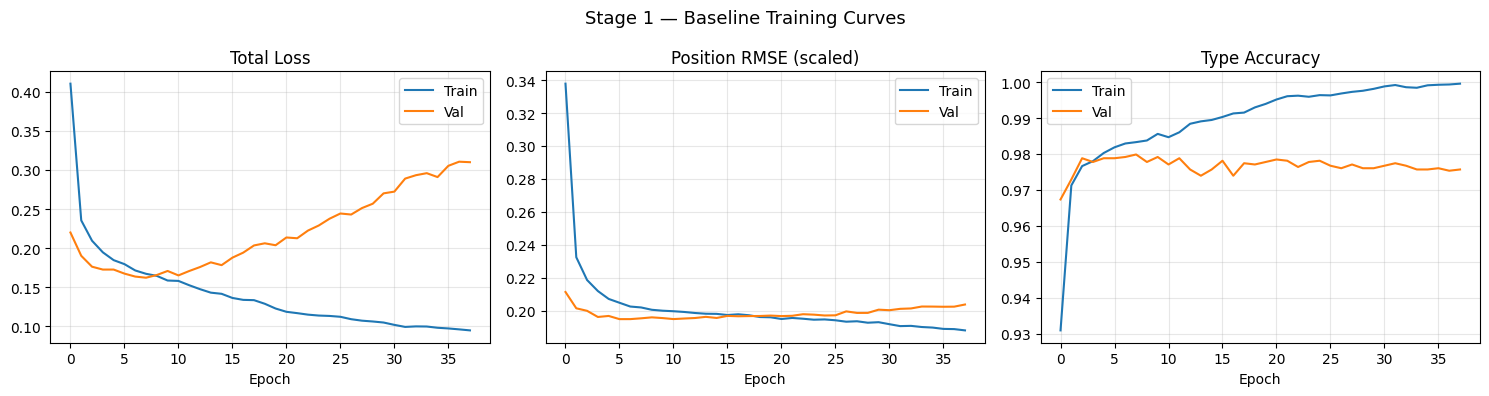


STAGE 2 — Optuna hyperparameter search


[I 2026-06-15 18:00:34,765] A new study created in RDB with name: magnetic_source_localization


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 10/50 | Train Loss: 0.2525 | Val Loss: 0.2567 | Val Loc RMSE: 0.2428 | Val Type Acc: 0.9788
Epoch 20/50 | Train Loss: 0.1977 | Val Loss: 0.2647 | Val Loc RMSE: 0.2128 | Val Type Acc: 0.9788
Early stopping triggered at epoch 27
[I 2026-06-15 18:02:20,229] Trial 0 finished with value: 0.24551008856958814 and parameters: {'n_layers': 4, 'hidden_dim': 512, 'decay_factor': 0.950392492774006, 'n_loc_layers': 3, 'n_type_layers': 1, 'dropout_rate': 0.1548270628429385, 'weight_decay': 1.9397664020856598e-05, 'use_residual': True, 'batch_size': 64, 'learning_rate': 0.0003081523162886588, 'bn_momentum': 0.07698737783782354, 'activation': 'silu', 'loc_weight': 1.1508258305981212, 'type_weight': 1.9144360284060316}. Best is trial 0 with value: 0.24551008856958814.
Epoch 10/50 | Train Loss: 0.4185 | Val Loss: 0.3708 | Val Loc RMSE: 0.2115 | Val Type Acc: 0.9565
Epoch 20/50 | Train Loss: 0.3646 | Val Loss: 0.3251 | Val Loc RMSE: 0.2007 | Val Type Acc: 0.9616
Epoch 30/50 | Train Loss: 0.3484 | V

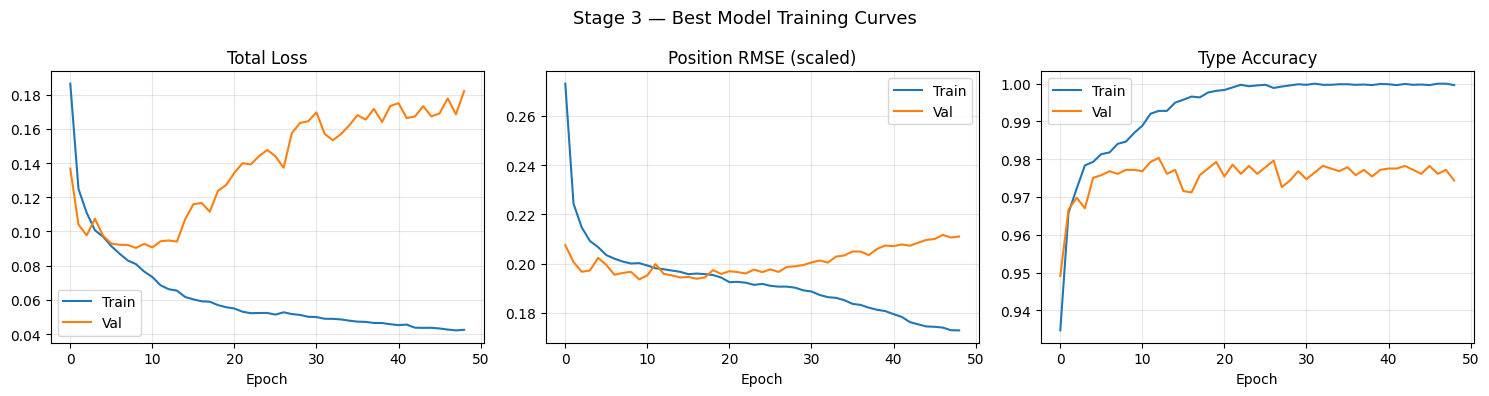

In [9]:
"""
Magnetic Source Identification — Training Entry Point

Run Stage 1 first to confirm the pipeline is working.
Once Stage 1 completes without error, run Stage 2 to search
the hyperparameter space with Optuna.
"""

import torch
import optuna
import matplotlib.pyplot as plt

# ── Device setup ────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')  # Should print cuda on a T4 GPU

# Reproducibility: seed torch/numpy (Optuna's search is seeded via TPESampler below).
# GPU floating-point ops may still introduce small run-to-run differences.
import numpy as np
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


# ============================================================
# STAGE 1 — Sanity-check run with default config
# ============================================================
# Purpose: confirm the full pipeline runs end-to-end before
# committing GPU time to an Optuna study.
#
# Expected rough outcome after 200 epochs on this dataset:
#   - Type accuracy  > 0.90  (classification is usually easy)
#   - Position RMSE  < 0.15  (in [0,1] scaled space)
# If either is far worse, check that data loaded correctly.

print('\n' + '='*60)
print('STAGE 1 — Default config sanity check')
print('='*60)

baseline_config  = ModelConfig()
baseline_model   = MultiTaskMagneticNet(baseline_config)
baseline_trainer = ModelTrainer(baseline_model, device, baseline_config)

baseline_history = baseline_trainer.train(
    train_loader,
    val_loader,
    epochs=200,
    early_stopping_patience=30,
)

baseline_test = baseline_trainer.evaluate(test_loader)
print(f'\nBaseline Test Results:')
print(f'  Position RMSE : {baseline_test["loc_rmse"]:.4f}  (scaled [0,1] space)')
print(f'  Type Accuracy : {baseline_test["type_acc"]:.4f}')

# ── Training curves ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Stage 1 — Baseline Training Curves', fontsize=13)

for ax, key, title in zip(
    axes,
    ['loss', 'loc_rmse', 'type_acc'],
    ['Total Loss', 'Position RMSE (scaled)', 'Type Accuracy'],
):
    ax.plot(baseline_history['train_history'][key], label='Train')
    ax.plot(baseline_history['val_history'][key],   label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# STAGE 2 — Optuna hyperparameter search
# ============================================================
# Only run this after Stage 1 completes successfully.
#
# What Optuna is tuning:
#   Architecture : n_layers, hidden_dim, decay_factor,
#                  n_loc_layers, n_type_layers, use_residual
#   Regularization: dropout_rate, weight_decay, bn_momentum
#   Training     : learning_rate, batch_size (32/64/128/256),
#                  activation (relu/silu/gelu)
#   Loss weights : loc_loss_weight, type_loss_weight
#
# n_trials=30 with n_epochs=50 takes roughly 1-2 hours on a T4.
# Increase n_trials or n_epochs after confirming it runs.

print('\n' + '='*60)
print('STAGE 2 — Optuna hyperparameter search')
print('='*60)

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='magnetic_source_localization',
    # SQLite storage persists results across Colab sessions.
    # If the session resets, re-run from Stage 2 and it will
    # pick up from where it left off.
    storage='sqlite:///optuna_experiment1.db',
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,   # let 5 trials run fully before pruning
        n_warmup_steps=10,    # never prune the first 10 epochs of a trial
    ),
)

study.optimize(
    lambda trial: objective(trial, train_loader, val_loader, device, n_epochs=50),
    n_trials=30,
    timeout=3600 * 2,  # hard stop at 2 hours regardless of n_trials
    show_progress_bar=True,
)

print(f'\nBest trial:')
print(f'  Val loss : {study.best_value:.4f}')
print(f'  Params   :')
for k, v in study.best_params.items():
    print(f'    {k:30s} = {v}')


# ============================================================
# STAGE 3 — Final model with best Optuna params
# ============================================================
# Trains for longer (300 epochs) with the winning config found
# by the Optuna study. This is the model you evaluate on the
# held-out clean test set in Part 4.

print('\n' + '='*60)
print('STAGE 3 — Final model with best params')
print('='*60)

best_config  = create_optuna_config(study.best_trial)
best_model   = MultiTaskMagneticNet(best_config)
best_trainer = ModelTrainer(best_model, device, best_config)

# Rebuild dataloaders with the winning batch size
final_train_loader = create_dataloader(
    train_loader.dataset.tensors[0].numpy(),
    train_loader.dataset.tensors[1].numpy(),
    train_loader.dataset.tensors[2].numpy(),
    batch_size=best_config.batch_size, shuffle=True,
)
final_val_loader = create_dataloader(
    val_loader.dataset.tensors[0].numpy(),
    val_loader.dataset.tensors[1].numpy(),
    val_loader.dataset.tensors[2].numpy(),
    batch_size=best_config.batch_size, shuffle=False,
)

best_history = best_trainer.train(
    final_train_loader,
    final_val_loader,
    epochs=300,
    early_stopping_patience=40,
)

# ── Final test evaluation ────────────────────────────────────
final_test_loader = create_dataloader(
    test_loader.dataset.tensors[0].numpy(),
    test_loader.dataset.tensors[1].numpy(),
    test_loader.dataset.tensors[2].numpy(),
    batch_size=best_config.batch_size, shuffle=False,
)

final_test = best_trainer.evaluate(final_test_loader)
print(f'\nFinal Model Test Results (clean, unseen data):')
print(f'  Position RMSE : {final_test["loc_rmse"]:.4f}  (scaled [0,1] space)')
print(f'  Type Accuracy : {final_test["type_acc"]:.4f}')

# ── Save the trained model ───────────────────────────────────
# Saves weights + config so you can reload without retraining.
torch.save(
    {
        'model_state_dict'  : best_model.state_dict(),
        'config'            : best_config,
        'best_val_loss'     : best_history['best_val_loss'],
        'test_loc_rmse'     : final_test['loc_rmse'],
        'test_type_acc'     : final_test['type_acc'],
        'axis_scalers'      : axis_scalers,
        'target_scaler'     : target_scaler,
    },
    'magnetic_model_experiment1.pt'
)
print('\nModel saved to magnetic_model_experiment1.pt')
print('Download it from the Colab file panel to keep it across sessions.')

# ── Final training curves ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Stage 3 — Best Model Training Curves', fontsize=13)

for ax, key, title in zip(
    axes,
    ['loss', 'loc_rmse', 'type_acc'],
    ['Total Loss', 'Position RMSE (scaled)', 'Type Accuracy'],
):
    ax.plot(best_history['train_history'][key], label='Train')
    ax.plot(best_history['val_history'][key],   label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4 · Key Findings & Forward Look

**Architecture doesn't gate performance at this scale.**
Across all 30 trials — networks ranging from 2 to 5 layers and 64 to 512 hidden units — the position RMSE spread was only ~1.5% (0.190 to 0.193). This is the central finding of Experiment 1: model capacity is not the bottleneck.

**GELU, no residual connections, batch_size=128, and a single classification layer** converged decisively. These four parameters are locked in all subsequent experiments.

**The RMSE plateau is a data ceiling, not a model ceiling.** The same ~0.191 RMSE regardless of architecture strongly suggests the limiting factor is the number of *unique source positions* in the training set (400), not the model's ability to learn from them.

**Momentum toward the next experiments:**
- *Experiment 2:* test whether loss function and optimizer tuning   (Huber β, grad_clip, LR scheduler factor) can move RMSE with the   same 400-position dataset.
- *Experiment 3:* restructure the dataset to 3,200 unique positions   (8× more independent spatial coverage) to test the data-ceiling hypothesis.
- *Experiment 4:* apply a spherical output constraint to address the   regression-toward-center failure mode identified in the final error analysis.